# Introduction

<h4><b>Research Question: </b> Predicting Crime Hotspots in Leeds using Economic Data</h4>

This notebook documents a project that aims to address the following research question, with an emphasis on using supervised machine learning in conjunction with spatial analysis techniques to achieve the desired results. Variables such as Unemployment, Average Income, and Deprivation Indices will be trained upon to determine the best predictor of crime. Different ML methods such as K-Nearest Neighbor and Decision Tree algorithms will be applied to compare their effectiveness, and analysis will be done to evaluate the overall accuracy of the final model. Through this process, conclusions will be drawn regarding the viability of Machine Learning in an urban crime context - and potential next steps or ways to improve in future. As expected this project has a grounding in urban science as well as data science, and the results of our data analysis are likely to have a great deal of real-world sociological context.

<b>Contents List</b>
1. <b>Background</b> - An overview of the topic of urban crime, how economic factors can influence it, and the modern data-driven approaches that have arisen to counter it.
2. <b>Data</b> - An introduction to the six datasets used in this project.
3. <b>Data Wrangling</b> - Code and documentation of the preprocessing stage of the project.
4. <b>Statistics and Visualisation</b> - Code-based review of the cleaned data's structure, with visual descriptors.
5. <b>Data Analysis</b> - Code for the main stage of project. Machine learning algorithms are trained, tested and predict crime rate using economic data as independent variables. Correlation analysis is also employed to determine relationship between variables, and spatial analysis is performed on crime maps.
6. <b>Results</b> - Explanation of Data Analysis outcomes. Prediction scores of different ML algorithms are discussed and contrasted with eachother.
7. <b>Discussion</b> - Results are broken down with code and examined to address research question. Key things to consider are the viability and accuracy of ML models for crime rate prediction.
8. <b>Conclusion</b> - Short summation of project.
9. <b>References</b> - List of academic sources used in this project.

# Background

Crime rates in UK cities have been a longstanding issue for the country, with reported increases in gang activity (Bennett and Holloway, 2004) in recent decades. There is a great deal of historical context that comes with this issue, as cities in the nineteenth century were notably rife with criminal activity for a number of factors (Churchill, 2013). By examining the root causes of crime and addressing them, cities can have improved quality of life and become safer for all. From an urban science perspective, multiple key factors leading to criminal activity have been identified. Socioeconomic conditions such as unemployment, low average incomes, and deprivation can be seen as the primary drivers of crime in both UK cities (Seddon, 2006, pp.680-681) and US cities (Allison, 1972). Gulma (2022) presents a pertinent case study of Leeds highlighting the effect of deprivation on crime rates. These sorts of conditions are what create the motivation to commit criminal acts, which Wilcox and Cullen (2018) state as the primary influence on crime rates - at least, according to traditional criminology. Thus, by examining a city's economy we can make educated deductions about its crime patterns.

This kind of statistical approach has been employed before to good effect. Analysing economic data can lead to key conclusions regarding variations in crime (Dnes, 2000). There is also a spatial component to crime (Freeman et al., 1996) that factors into data science efforts, with different concentrations and patterns emerging across geographic divisions. For instance, Brantingham and Brantingham (1982) posited that offenders develop an 'awareness space' as they travel around a city that subsequently dictates where they commit crimes. Spatial crime analysis of Leeds in particular has been undertaken before - Kongmuang (2006) wrote a thesis that focuses on the potential of spatial microsimulation for crime modelling in the city, concluding that such methods were effective at small area levels such as individual wards. The practical applications of this are well-established; simply knowing the geographic and statistical patterns of crime allows policymakers to derive strategies to counter it.

Predictive policing goes further by incorporating machine learning algorithms to create a "spatiotemporal forecast" (Hardyns and Rummens, 2017, p.203) of crime hotspots based on historical data, a process this project aims to emulate. Meijer and Wessels speak positively of this practice, stating that statistic models provided "immense value for reducing crime and ensuring the safety in cities." (Meijer and Wessels, 2019, p.1031). It should be noted, however, that there are vocal critics of data-driven approaches to crime prediction. The lack of transparency in machine learning models is cause for concern, and they can potentially create inequality by causing over-policing of certain neighborhoods (Meijer and Wessels, 2019, p.1037). We must be consider these drawbacks when undertaking this project - we do not want to repeat past mistakes.

# Data

There are six distinct datasets being used in this project. While all are read in as pandas (or geopandas) dataframes, they have varying origins and purposes in this project. Something to keep in mind is the time period of this data; data has been exclusively sourced from either the 2011 census or 2019 IMD findings to ensure consistency.

The first dataset is a <code>.shp</code> file supplied by the Office of National Statistics that details the geographical boundaries of each Lower Super Output Area (LSOA) in the UK. It is very large in size, with 34,753 records that each contain detailed numerical data. There are 2 columns for LSOA code and name, and an additional 7 columns for geometry data such as coordinates and shape area. This adds up to create a .shp file roughly 214MB in size. We require only the 482 LSOA boundaries that make up Leeds, so some preprocessing will be required to avoid dealing with superfluous data. This dataset will serve as the foundational spatial map that we use to visualise various factors that differ across metropolitan divisions.

The next four datasets are <code>.csv</code> files that both originate from Leeds Observatory, a website that provides datasets concerning the population and economy of Leeds. The datasets are intended for public use, and regularly updated - this data in particular has been sourced from the 2011 Census. The first contains our key crime statistics: the 12-month rolling rates for all types of criminal activity grouped by LSOA from January 2011 to December 2011. The crime reports recorded here are sourced from police data and include (but are not limited to) Anti-social behaviour, Shoplifting, Bike theft, Drug possession, Burglary, Violence and Public disorder. Each rate represents the number of crime incidents per 1,000 population that occurred throughout the year. There is an alternate count-based dataset with pure integer values, but this one was chosen as it is a more proportional figure that factors in population density. The second dataset records unemployment statistics; specifically the percentage of people in each LSOA who were long-term unemployed in 2011. The 'long-term' distinction (meaning a period of joblessness longer than 6 months) is important here. While unemployment can vary for a great number of reasons, significant long-term unemployment is generally a symptom of a poor economy in the area (Nichols et al., 2013, p.2) and may therefore be a better predictor. A similar percentage-based dataset has been found for Car Availability, which records the proportion of households without access to a car or van. Lack of car ownership is generally correlated with lower incomes (Dargay, 2001), so this may be able to aid with prediction. Finally, a dataset for the proportion of economically-active residents in an area has been used. The economic grounding of this dataset is self-evident, and it may help this project's ML model identify prosperous crime-free LSOAs. Alternatively, it may be that economic activity in an area creates opportunity and therefore increases crime rates - the results from our data analysis will tell us which of these assumptions is more accurate to Leeds. Unlike the boundaries dataset, these four datasets have only 482 Leeds-based records so no initial cropping is needed.

The last dataset is slightly different both in format and source. It is taken from Leeds City Council's Arcgis Online repository as an <code>.xslx</code> file, which for all intents and purposes operates similar to a <code>.csv</code> file. The dataset contains rankings for the Index of Multiple Deprivation (IMD) of Leeds LSOAs in 2019, with 59 columns for different metrics. The IMD is the official government measurement of deprivation for neighborhoods in the UK, ranking all LSOAs in ascending order of deprivation - the area ranked #1 is most deprived and #32,844 the least (Department for Communities and Local Government, 2015). There are subtypes of deprivation listed in each column such as Housing, Health, Adult Skills and so on. This dataset will provide the main economic context for each LSOA, allowing for ML algorithms to be tested with a diverse array of parameters to understand the specific socioeconomic causes (or symptoms) of crime rates. There are also columns for crime here - whilst only a ranking instead of a quantifiable rate, this metric will provide an important 2019 reference point to test prediction models on.

<b>2011 LSOA Shapefile:</b> https://geoportal.statistics.gov.uk/datasets/357ee15b1080431491bf965394090c72_0/

<b>2011 Crime CSV:</b> https://observatory.leeds.gov.uk/crime-and-community-safety/map/

<b>2011 Unemployment, Car Availability and Economic Activity CSVs:</b> https://observatory.leeds.gov.uk/economy-and-employment/map/

<b>2019 Deprivation XLSX:</b> https://leedscc.maps.arcgis.com/apps/View/index.html?appid=c7654fdc77044d8cb6019a947506f3fa



# Data Wrangling

The first step in this project is importing all relevant python libraries. Pandas will be the principal module for handling datasets, Seaborn and Matplotlib will allow for visualisation, libpysal will let us calculate Moran's I values and scikit-learn will provide all machine learning functionality.

In [ ]:
# Data Handling
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
import numpy as np

# Statistics and Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import libpysal
from libpysal import weights
import pysal
from pysal.explore import esda

# Machine Learning
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

Then, the files discussed in the <b>Data</b> section need to be read into datasets. The LSOA boundary dataset requires a <code>geodataframe</code> as it represents spatial data.

In [ ]:
# Office of National Statistics Data
LSOA_boundaries = gpd.read_file('LSOA_2011_EW_BFC_V3.shp')

# Leeds Observatory Data
crime = pd.read_csv('All Crime Rate (Jan-11 - Dec-11).csv')
deprivation = pd.read_excel('Full-IMD-results-for-Leeds.xlsx')
unemployment = pd.read_csv('Long-term unemployed % (2011).csv')
cars = pd.read_csv('No cars or vans in household % (2011).csv')
economic_activity = pd.read_csv('Economically active % (2011).csv')

As mentioned earlier, the LSOA Boundary file contains all 34,753 boundaries for the UK - vastly too much data to deal with. We can filter this down using the LSOA11NM column as it contains the name of the city or town LSOAs are part of. A check for LSOA11NM rows that contain the word 'Leeds' lets us crop it down to the relevant 482 entries.

In [ ]:
LSOA_boundaries = LSOA_boundaries[LSOA_boundaries['LSOA11NM'].str.contains('Leeds', case=False, na=False)]

print("Length of filtered Boundaries dataset: ", len(LSOA_boundaries))

Length of filtered Boundaries dataset:  482


We will also drop superfluous geographic columns - <code>geometry</code> is the only one we need for spatial mapping.

In [ ]:
LSOA_boundaries_dropped = LSOA_boundaries.drop(columns=['LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng', 'GlobalID'])

First, a check for null values across all datasets.

In [ ]:
# Find and print No. of null values in different columns
def null_check(dataset):
    null_col_sums = dataset.isnull().sum()
    cols_with_null_values = null_col_sums[null_col_sums > 0]
    print(cols_with_null_values)

null_check(crime)
null_check(deprivation)
null_check(unemployment)
null_check(LSOA_boundaries_dropped)

Series([], dtype: int64)
IMD - most deprived 1%, 3% or 5% in England\n    466
Unnamed: 8                                       437
Unnamed: 9                                       422
dtype: int64
Series([], dtype: int64)
Series([], dtype: int64)


The 'Most deprived' percentile columns appear to be mostly null. This is expected, as these columns only contain a float value (0.01, 0.03, or 0.05) if the corresponding LSOA is one of the most deprived in the entire country. It would make more sense to convert these columns into boolean as the statistic they represent only has two logical values - yes or no. Hence, we can safely convert the null values to FALSE and non-null values to TRUE.

In [ ]:
def convert_to_boolean(column):
    deprivation.loc[1:, column] = deprivation.loc[1:, column].mask(pd.notna(deprivation[column]), True)
    deprivation.loc[1:, column] = deprivation.loc[1:, column].mask(pd.isna(deprivation[column]), False)

convert_to_boolean('IMD - most deprived 1%, 3% or 5% in England\n')
convert_to_boolean('Unnamed: 8')
convert_to_boolean('Unnamed: 9')

The previous code has brought to light that the IMD dataset has incorrectly formatted column names due to having two rows for its header, which also increases the number of rows to 483. All datasets used should have 482 rows exactly - one for each LSOA, so we will convert the top row into our header and discard the superheadings.

In [ ]:
deprivation.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Index of Multiple Deprivation \n(all 7 domains combined)\nDecile 1 is the most deprived 10% in England,Unnamed: 5,Unnamed: 6,"IMD - most deprived 1%, 3% or 5% in England\n",Unnamed: 8,Unnamed: 9,...,Unnamed: 49,Wider barriers sub-domain of Barriers to Housing and Services,Unnamed: 51,Unnamed: 52,Indoors sub-domain of Living Environment,Unnamed: 54,Unnamed: 55,Outdoors sub-domain of Living Environment,Unnamed: 57,Unnamed: 58
0,LSOA,LSOA Name,Ward code (2018 version),Ward (2018 version),IMD Rank in England,IMD Rank in Leeds,IMD Decile,Most deprived 1%,Most deprived 3%,Most deprived 5%,...,Geo barriers Decile,Wider barriers Rank in England,Wider barriers Rank in Leeds,Wider barriers Decile,Indoors Rank in England,Indoors Rank in Leeds,Indoors Decile,Outdoors Rank in England,Outdoors Rank in Leeds,Outdoors Decile
1,E01011372,"Stratford Street, Beverleys",E05011399,Hunslet and Riverside,22,1,1,True,True,True,...,10,1111,2,1,860,34,1,1845,18,1
2,E01011368,"Crosby St, Recreations, Bartons",E05011386,Beeston and Holbeck,37,2,1,True,True,True,...,10,4209,42,2,889,35,1,4112,64,2
3,E01033035,Lincoln Green,E05011388,Burmantofts and Richmond Hill,66,3,1,True,True,True,...,10,2276,9,1,1150,43,1,1284,10,1
4,E01011667,"Foundry Mill Drive, Hawkshead Cres, Alston Lane",E05011400,Killingbeck and Seacroft,113,4,1,True,True,True,...,8,5105,64,2,7006,184,3,7584,179,3


In [ ]:
# Convert first row to header and drop unnecessary superheading
deprivation.columns = deprivation.iloc[0]
deprivation = deprivation.iloc[1:]

59 Columns is too many to deal with for this project, so non-decile based columns will be dropped as well as ward-related data. Some more niche IMD columns will be removed also, as they are unlikely to play an important role in the analysis.

In [ ]:
deprivation_dropped = deprivation.drop(columns=['LSOA Name', 'Ward code (2018 version)', 'Ward (2018 version)',
                          'IMD Rank in England', 'Income Rank in England', 'Income Rank in Leeds',
                          'Emp Rank in England', 'Emp Rank in Leeds', 'Edu Rank in England',
                          'Edu Rank in Leeds', 'Health Rank in England', 'Health Rank in Leeds',
                          'Crime Rank in England', 'Crime Rank in Leeds', 'Housing Rank in England',
                          'Housing Rank in Leeds', 'Env Rank in England', 'Env Rank in Leeds',
                          'IDACI Rank in England', 'IDACI Rank in Leeds', 'IDACI Decile', 'IDACI rate',
                          'IDAOPI Rank in England',	'IDAOPI Rank in Leeds',	'IDAOPI Decile', 'IDAOPI rate',
                          'YP edu Rank in England',	'YP edu Rank in Leeds', 'Adult skills Rank in England',
                          'Adult skills Rank in Leeds', 'Geo barriers Rank in England', 'Geo barriers Rank in Leeds',
                          'Geo barriers Decile', 'Wider barriers Rank in England', 'Wider barriers Rank in Leeds',
                          'Wider barriers Decile', 'Indoors Rank in England', 'Indoors Rank in Leeds',
                          'Outdoors Rank in England', 'Outdoors Rank in Leeds'])

num_columns = [
    'IMD Rank in Leeds', 'IMD Decile', 'Income Decile', 'Emp Decile',
    'Edu Decile', 'Health Decile', 'Crime Decile', 'Housing Decile',
    'Env Decile', 'YP edu Decile', 'Adult skills Decile',
    'Indoors Decile', 'Outdoors Decile', '% income deprived', '% employment deprived']

deprivation_dropped[num_columns] = deprivation_dropped[num_columns].apply(pd.to_numeric, errors='coerce')

deprivation_dropped.info()
deprivation_dropped.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 1 to 482
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LSOA                   482 non-null    object 
 1   IMD Rank in Leeds      482 non-null    int64  
 2   IMD Decile             482 non-null    int64  
 3   Most deprived 1%       482 non-null    object 
 4   Most deprived 3%       482 non-null    object 
 5   Most deprived 5%       482 non-null    object 
 6   Income Decile          482 non-null    int64  
 7   % income deprived      482 non-null    float64
 8   Emp Decile             482 non-null    int64  
 9   % employment deprived  482 non-null    float64
 10  Edu Decile             482 non-null    int64  
 11  Health Decile          482 non-null    int64  
 12  Crime Decile           482 non-null    int64  
 13  Housing Decile         482 non-null    int64  
 14  Env Decile             482 non-null    int64  
 15  YP edu

,LSOA,IMD Rank in Leeds,IMD Decile,Most deprived 1%,Most deprived 3%,Most deprived 5%,Income Decile,% income deprived,Emp Decile,% employment deprived,Edu Decile,Health Decile,Crime Decile,Housing Decile,Env Decile,YP edu Decile,Adult skills Decile,Indoors Decile,Outdoors Decile
1,E01011372,1,1,True,True,True,1,0.450,1,0.379,1,1,1,2,1,1,1,1,1
2,E01011368,2,1,True,True,True,1,0.477,1,0.409,1,1,1,4,1,1,1,1,2
3,E01033035,3,1,True,True,True,1,0.453,1,0.308,1,1,1,3,1,1,1,1,1
4,E01011667,4,1,True,True,True,1,0.567,1,0.337,1,1,1,4,3,1,1,3,3
5,E01011662,5,1,True,True,True,1,0.438,1,0.367,1,1,1,2,3,1,1,3,3


Some additional pre-processing is required. Each dataset has all 482 LSOA codes listed in each row, but sometimes there is unnecessary data included. The <code>crime</code> dataset shows this with its lengthy comma-separated <code>Name</code> fields.

In [ ]:
crime.head()

,Name,All Crime Rate (Jan-11 - Dec-11)
0,"E01011264, Hawthorns, Coppice Wood Cres",24.24
1,"E01011265, Guiseley Railway Station, Town Cent...",126.94
2,"E01011266, Highroyds, Tranmere Estate",25.34
3,"E01011267, West Queensway, Greenbottom",65.14
4,"E01011268, Coppice Woods, Shaws, Nunroyd Park",54.29


Some parsing is done to extract the LSOA code (LSOA11CD) in each dataset.

In [ ]:
# First 9 characters of each 'Name' entry is the code

crime['Name'] = crime['Name'].str[:9]
unemployment['Name'] = unemployment['Name'].str[:9]
cars['Name'] = cars['Name'].str[:9]
economic_activity['Name'] = economic_activity['Name'].str[:9]

Columns in each dataset are also renamed to ensure consistency and keep references brief.

In [ ]:
crime.rename(columns={"Name": "LSOA11CD", "All Crime Rate (Jan-11 - Dec-11)": "Crime Rate (2011)"}, inplace=True)
unemployment.rename(columns={"Name": "LSOA11CD"}, inplace=True)
cars.rename(columns={"Name": "LSOA11CD"}, inplace=True)
economic_activity.rename(columns={"Name": "LSOA11CD"}, inplace=True)
deprivation_dropped.rename(columns={"LSOA": "LSOA11CD"}, inplace=True)

With all datasets now having consistently formatted LSOA11CD columns, they can be joined together into a spatial dataset for deprivation as well as an overall statistical spatial dataset for the 2011 data.

In [ ]:
spatial_deprivation = deprivation_dropped.merge(LSOA_boundaries_dropped, how='left', on='LSOA11CD')
LSOA_statistics = crime.merge(unemployment, how='left', on='LSOA11CD'
                             ).merge(cars, how='left', on='LSOA11CD'
                             ).merge(economic_activity, how='left', on='LSOA11CD'
                             ).merge(LSOA_boundaries_dropped, how='left', on='LSOA11CD')

deprivation_by_LSOA = GeoDataFrame(spatial_deprivation, geometry='geometry')
LSOA_statistics = GeoDataFrame(LSOA_statistics, geometry='geometry')

# Statistics and Visualisation

## Part 1: LSOA_statistics

With our initial datasets cleaned and joined, we can examine their structure in detail. We'll start with LSOA_statistics, which has 5 columns and 482 rows.

In [ ]:
LSOA_statistics.info()
LSOA_statistics.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   LSOA11CD                               482 non-null    object  
 1   Crime Rate (2011)                      482 non-null    float64 
 2   Long-term unemployed % (2011)          482 non-null    float64 
 3   No cars or vans in household % (2011)  482 non-null    float64 
 4   Economically active % (2011)           482 non-null    float64 
 5   geometry                               482 non-null    geometry
dtypes: float64(4), geometry(1), object(1)
memory usage: 22.7+ KB


,LSOA11CD,Crime Rate (2011),Long-term unemployed % (2011),No cars or vans in household % (2011),Economically active % (2011),geometry
0,E01011264,24.24,1.4,20.5,71.4,"POLYGON ((421248.688 442315.812, 421284.072 44..."
1,E01011265,126.94,1.8,27.0,79.4,"POLYGON ((418635 442559, 418637.561 442552.855..."
2,E01011266,25.34,0.4,6.9,80.8,"POLYGON ((417783.688 443382.312, 417788.688 44..."
3,E01011267,65.14,2.0,29.1,72.0,"POLYGON ((419607.843 442388.568, 419612.752 44..."
4,E01011268,54.29,2.1,35.0,70.4,"POLYGON ((420442.406 442436.687, 420443.313 44..."


* <b>LSOA11CD</b> is a 9-digit string column that contains unique codes for each LSOA formed of both numbers and letters. It follows an ascending order as the numerical segment increments by 1 with each new record. This variable is shared with the IMD dataframe - it is a unique identifier for each area of Leeds.
* <b>Crime Rate (2011)</b> is a 2-point float value representing the proportional frequency of crime in an area. If this value were to equal 50.0, then that means 50 criminal cases occurred per 1,000 population in that LSOA from the period of Jan 2011-Dec 2011.
* <b>Long-term unemployed % (2011)</b> is a single point float for the percentage of people who have been unemployed for six or more months in an area. This variable has the lowest average of all percentage values.
* <b>No cars or vans in household % (2011)</b> is another single point float which represents the percentage of households without access to a car or van.
* <b>Economically active % (2011)</b> is a single point float for the percentage of people who are economically active in an area. This variable has the highest average of all percentage values.
* <b>geometry</b> is a special column of the <code>geometry</code> type used to represent spatial data.

For a broad overview of the data, we'll start by creating a statistical summary as well as a combined violin-boxplot of key values. This will help us identify trends as well as outliers within the data.

count     482.00
mean       96.17
std       126.36
min         9.85
25%        44.56
50%        74.18
75%       115.65
max      2058.07
Name: Crime Rate (2011), dtype: float64


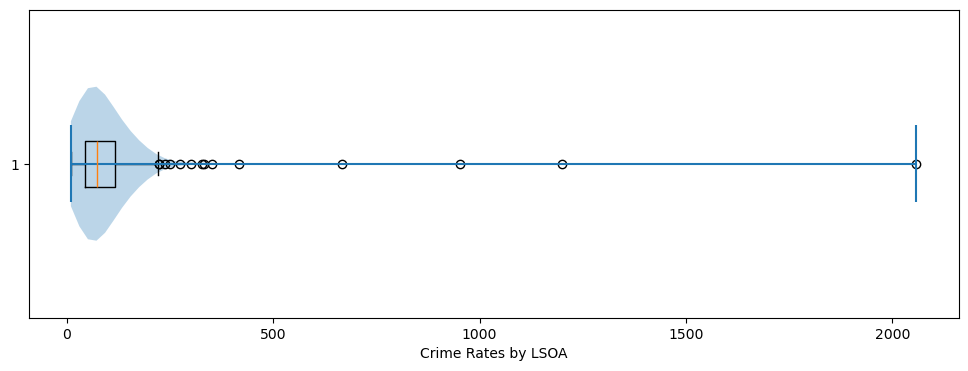

In [ ]:
print(round(LSOA_statistics['Crime Rate (2011)'].describe(), 2))

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

# Boxplot of 2011 Crime Rates
plt.boxplot(LSOA_statistics['Crime Rate (2011)'], vert=False)
plt.violinplot(LSOA_statistics['Crime Rate (2011)'], vert=False)
plt.xlabel("Crime Rates by LSOA")

plt.show()

From the above statistical overview and boxplot, there are several conclusions to be drawn. The violin plot's bulge and lower and upper quartiles tell us that the majority of crime rates in Leeds are within the range of 44.56 and 74.18 but trend towards the lower half of that range. Yet the width of the violin plot at the absolute minimum point means there is still a relatively large distribution of LSOAs on the bottom of the scale, implying that a not-insignificant number of LSOAs have minimal crime rates.  While there are a substantial amount of outliers, four extreme cases can be observed with crime rates that range from 500 to 2058.07. As it is likely these values do correspond to real crime rates, we will not remove them - but their effect on data analysis will be taken into account.

As we are looking to predict a target variable, it also would be prudent to examine the relationships between different variables. The most effective way to percieve these relationships is with a color-coded heatmap. This will inform which variables are best to use in our model as independent variables.

Text(0.5, 1.0, 'Correlation Heatmap of 2011 LSOA statistics')

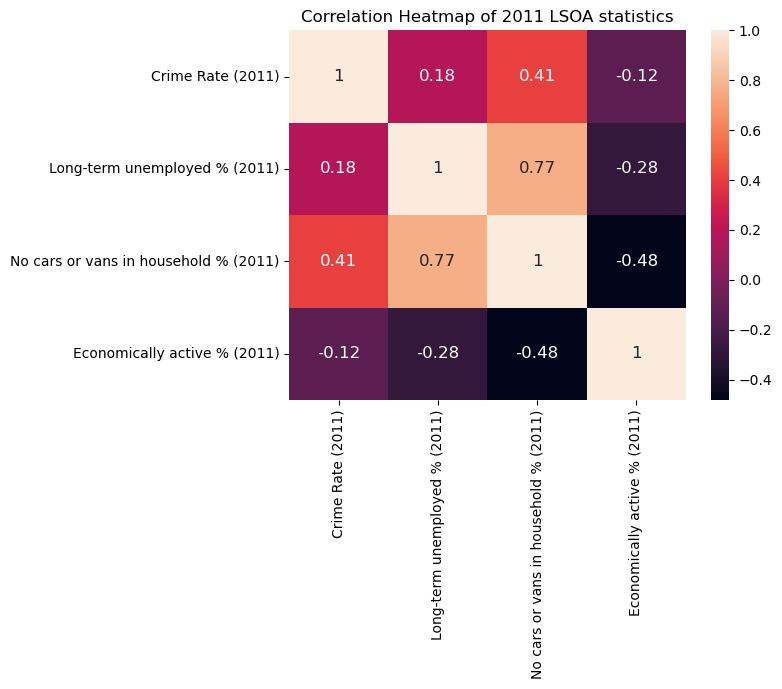

In [ ]:
statistic_correlations = LSOA_statistics.iloc[:,[1,2,3,4]].corr()

ax = plt.axes()
sns.heatmap(data = statistic_correlations,
            annot=True,
            annot_kws={"size": 12},
            ax = ax)

ax.set_title('Correlation Heatmap of 2011 LSOA statistics')

This heatmap immediately illustrates that 'No cars or vans in household % (2011)' has the strongest correlation with 'Crime Rate (2011)' at 0.41. The correlation is positive, which indicates that a rise in the rate of car ownership causes a decrease in crime. Of note is the fact that this same variable is very strongly correlated with 'Long-term unemployed % (2011)' at 0.77, implying a strong (potentially causal) link between car ownership and employment - yet unemployment itself evidently has only a small correlation with crime at 0.18. Economic activity has a similarly minor correlation with crime, yet in the negative.

Creating a scatter plot of 'No cars or vans in household % (2011)' and 'Crime Rate (2011)' helps illustrate the kind of positive correlation they have. The line of best fit's gradient is slight, but an upwards trend can be seen. Interestingly, our extreme outliers are exclusively on the higher end of the spectrum in regards to lack of car ownership.

Text(0.5, 0, 'Crime Rates by No cars or vans in household %')

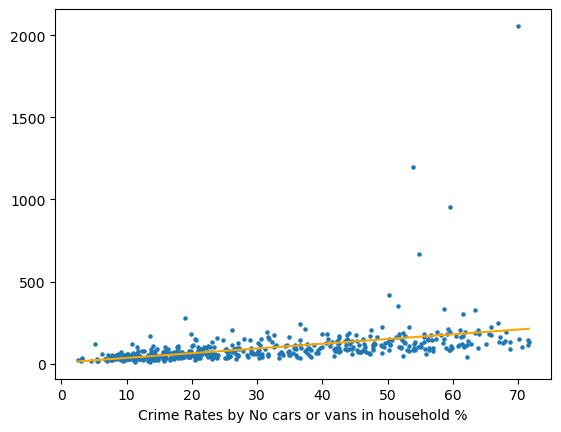

In [ ]:
plt.scatter(LSOA_statistics['No cars or vans in household % (2011)'], LSOA_statistics['Crime Rate (2011)'], s=5)
plt.plot(np.unique(LSOA_statistics['No cars or vans in household % (2011)']),
         np.poly1d(np.polyfit(LSOA_statistics['No cars or vans in household % (2011)'], LSOA_statistics['Crime Rate (2011)'], 1))
         (np.unique(LSOA_statistics['No cars or vans in household % (2011)'])), color='orange')
plt.xlabel("Crime Rates by No cars or vans in household %")

## Part 2: deprivation_by_LSOA

The <code>deprivation_by_LSOA</code> GeoDataframe is our secondary source of socioeconomic and criminal data in Leeds. It is more complex that <code>LSOA_statistics</code> with 20 columns and 482 rows.

In [ ]:
deprivation_by_LSOA.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   LSOA11CD               482 non-null    object  
 1   IMD Rank in Leeds      482 non-null    int64   
 2   IMD Decile             482 non-null    int64   
 3   Most deprived 1%       482 non-null    object  
 4   Most deprived 3%       482 non-null    object  
 5   Most deprived 5%       482 non-null    object  
 6   Income Decile          482 non-null    int64   
 7   % income deprived      482 non-null    float64 
 8   Emp Decile             482 non-null    int64   
 9   % employment deprived  482 non-null    float64 
 10  Edu Decile             482 non-null    int64   
 11  Health Decile          482 non-null    int64   
 12  Crime Decile           482 non-null    int64   
 13  Housing Decile         482 non-null    int64   
 14  Env Decile             482 non-nul

* <b>LSOA11CD</b> is the same 9-digit code used by <code>LSOA_statistics</code> as a unique identifier.
* <b>IMD Rank in Leeds</b> is a continuous value that ranges from 1-482, assigned based on an LSOA's position in a Leeds-based ranking of the Index of Multiple Deprivation.
* The <b>Most Deprived X%</b> columns are a list of boolean values that confirm whether an LSOA exists within the top 1%, 3% or 5% most deprived in the England. There is overlap, meaning LSOAs with TRUE values in the 1% column have the same value in 3% and 5%.
* The <b>X Decile</b> columns contain object-type values that represent which 10% bracket . A value of 1 would indicate that an LSOA is within the top 10% for that particular measure of deprivation, a value of 2 for top 20% and so on. It is therefore important to note a lower decile is negative - LSOAs should ideally be in the higher deciles as this means they are ranked lower on the scale of deprivation.
* <b>% income deprived</b> is a 3-point float value representing the "proportion of the population experiencing deprivation relating to low income" (Ministry of Housing, 2019). It is a decimal conversion of a percentage, so a value of 0.5 would be equivalent to 50%.
* <b>% employment deprived</b> is similar to the previous column, a 3-point float value representing the "proportion of the working-age population in an area involuntarily excluded from the labour market" (Ministry of Housing, 2019).

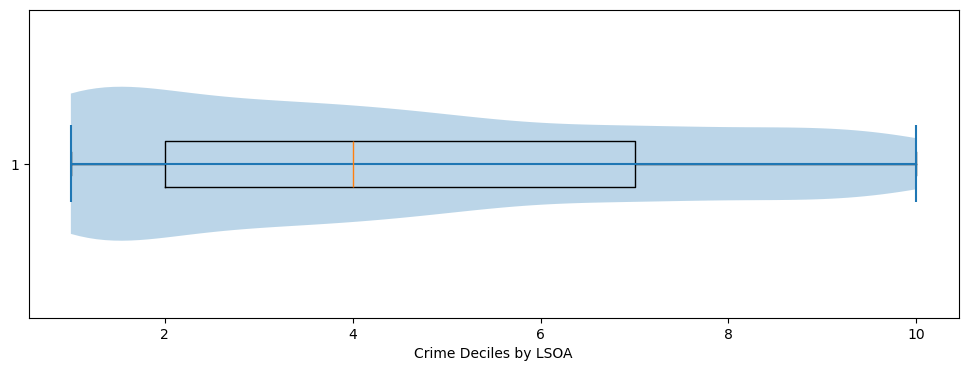

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

# Boxplot of 2019 Crime Deciles
plt.boxplot(deprivation_by_LSOA['Crime Decile'], vert=False)
plt.violinplot(deprivation_by_LSOA['Crime Decile'], vert=False)
plt.xlabel("Crime Deciles by LSOA")

plt.show()

As it concerns UK deciles rather than flat rates, this violin-boxplot can tell us more about Leeds' crime situation in relation to other cities. In particular, Leeds is among the lower ranked cities for crime with its median of 4th Decile. The decile ranking system is unique as it means we can effectively treat this column as both continuous integer data and a categorical series with 10 groups. It also means we have a much more gradual distribution of values and there are no outliers to consider.

Once again, a heatmap of IMD Deciles is plotted to find which socioeconomic factors are closely intertwined with others.

Text(0.5, 1.0, 'Correlation Heatmap of IMD Metrics')

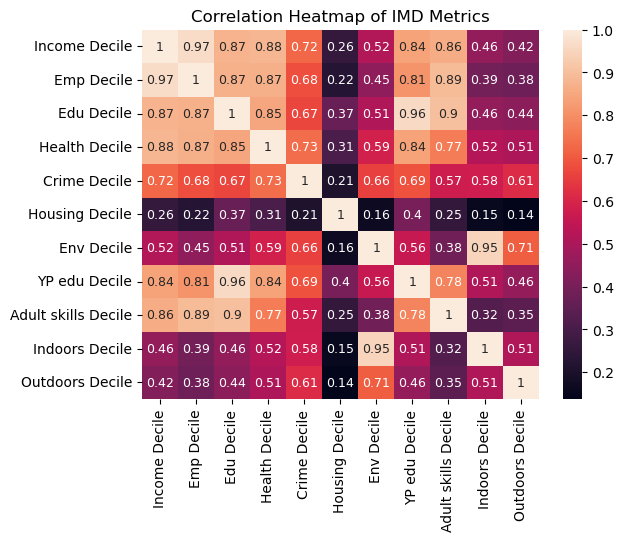

In [ ]:
deprivation_correlations = deprivation_by_LSOA.iloc[:, [6,8,10,11,12,13,14,15,16,17,18]].corr()

ax = plt.axes()
sns.heatmap(data = deprivation_correlations,
            annot=True,
            annot_kws={"size": 9},
            ax = ax)

ax.set_title('Correlation Heatmap of IMD Metrics')

This produces a vast range of correlation coefficients with interesting implications, but what matters most are those relevant to the Crime Decile column. It seems primarily correlated with Health and Income deprivation as their correlation coefficients are highest (0.72 and and 0.73 respectively), although not by an especially large margin. Although it is not relevant to this project, the deprivation of Housing interestingly seems to have consistently weak correlation with most other measures of deprivation, which implies housing quality as having only a minor effect on an area's conditions.

## Part 3: Spatial Visualisation

Spatially plotting various statistics according to LSOA gives us the following maps. Negative factors are colour-coded red and positive ones are colour-coded green.

[]

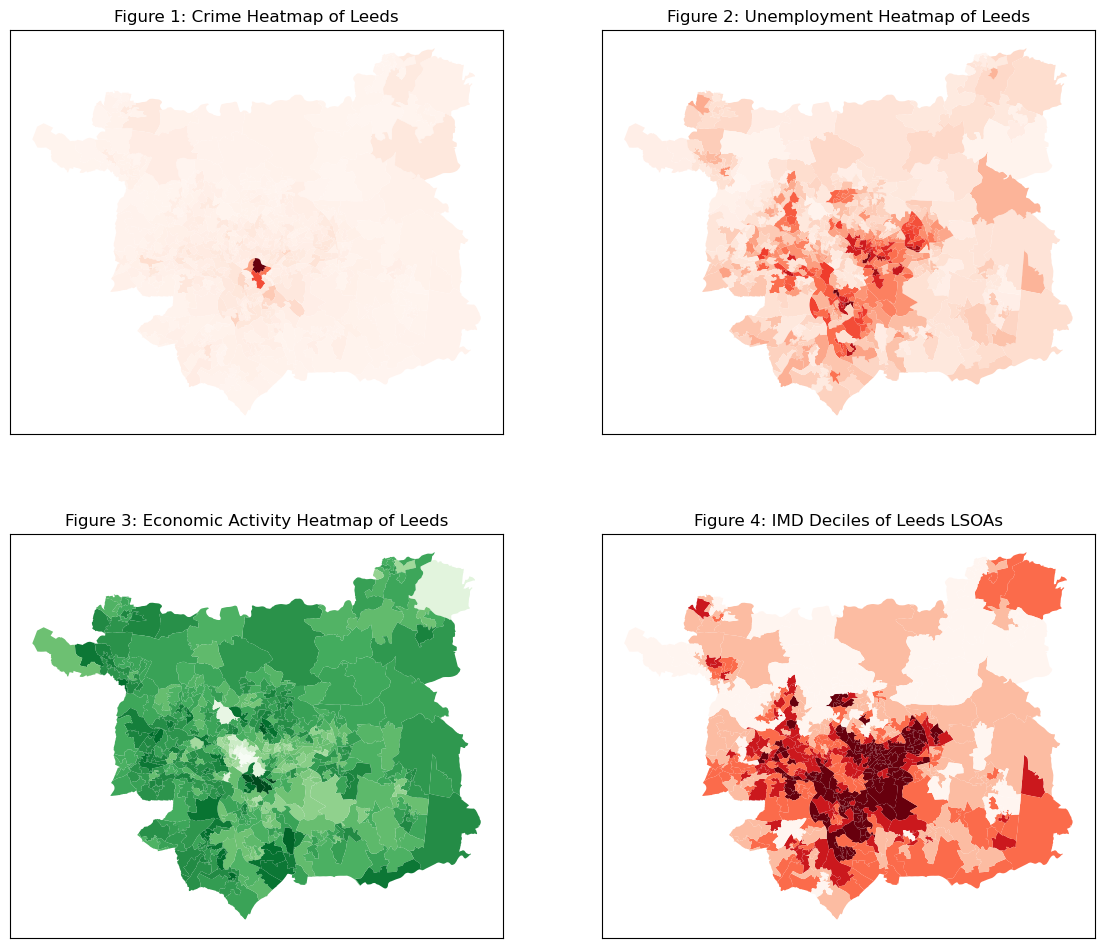

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

LSOA_statistics.plot(column="Crime Rate (2011)", ax=axes[0, 0], cmap="Reds")
axes[0, 0].set_title("Figure 1: Crime Heatmap of Leeds")
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])
LSOA_statistics.plot(column="Long-term unemployed % (2011)", ax=axes[0, 1], cmap="Reds")
axes[0, 1].set_title("Figure 2: Unemployment Heatmap of Leeds")
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])
LSOA_statistics.plot(column="Economically active % (2011)", ax=axes[1, 0], cmap="Greens")
axes[1, 0].set_title("Figure 3: Economic Activity Heatmap of Leeds")#
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])
deprivation_by_LSOA.plot(column="IMD Decile", ax=axes[1, 1], cmap="Reds_r", scheme="Quantiles")
axes[1, 1].set_title("Figure 4: IMD Deciles of Leeds LSOAs")
axes[1, 1].set_xticks([])
axes[1, 1].set_yticks([])

<b>Figure 1</b> clearly visualises the extreme outliers shown in the earlier boxplot to the extent where the rest of the spatial plot becomes less readable. This has given us some important geographic context for the outliers, namely that they all occur within the City Centre or in an adjacent LSOA.

<b>Figure 2 and 4</b> . Despite originating from different government sources over 8 years apart, the same pattern of impoverishment can be observed. The city centre and surrounding areas appear quite well-off, while outlying residential areas have more problems. The University of Leeds Campus and Headingley areas in the north-west of Leeds appear to be as productive as the city centre despite their lack of economic activity as shown in <b>Figure 3</b> - this may be something to do with the large student population in these LSOAs.

[]

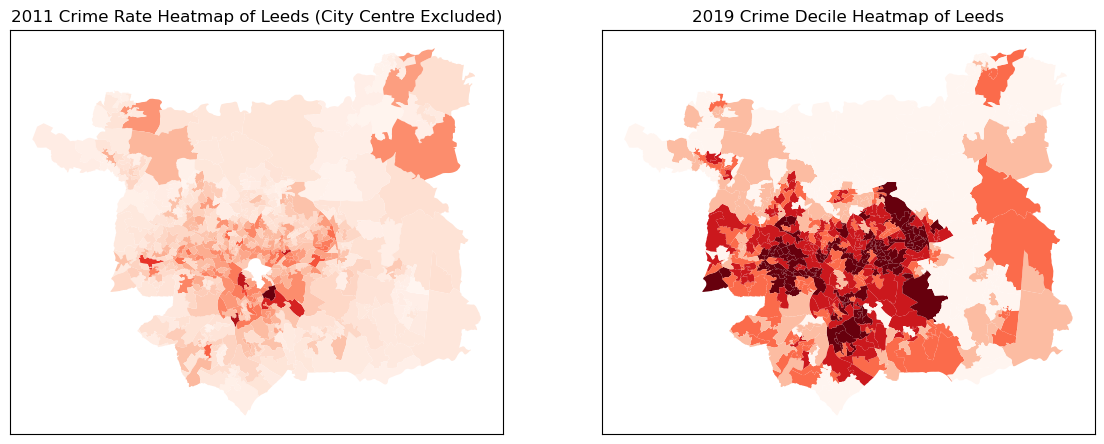

In [ ]:
LSOA_statistics_no_outliers = LSOA_statistics[LSOA_statistics['Crime Rate (2011)'] < 500]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

LSOA_statistics_no_outliers.plot(column="Crime Rate (2011)", ax=axes[0], cmap="Reds")
axes[0].set_title("2011 Crime Rate Heatmap of Leeds (City Centre Excluded)")
axes[0].set_xticks([])
axes[0].set_yticks([])
deprivation_by_LSOA.plot(column="Crime Decile", ax=axes[1], scheme="Quantiles", cmap="Reds_r")
axes[1].set_title("2019 Crime Decile Heatmap of Leeds")
axes[1].set_xticks([])
axes[1].set_yticks([])

Checking the Moran's I values confirms that there is a spatial autocorrelation of crime in both our datasets. Both of these values are significant as their p-values are beneath 0.05. Our IMD dataset, however, appears to have stronger spatial autocorrelation as its Moran's I value is larger by about 0.3.

In [ ]:
knn_weights = weights.KNN.from_dataframe(LSOA_statistics, geom_col = 'geometry', ids = 'LSOA11CD', k = 20)
morans = esda.Moran(LSOA_statistics['Crime Rate (2011)'], knn_weights)
print("LSOA_statistics has a Moran's I value of ", morans.I)
print("LSOA_statistics has a Moran's p-value of ", morans.p_sim)

knn_weights = weights.KNN.from_dataframe(deprivation_by_LSOA, geom_col = 'geometry', ids = 'LSOA11CD', k = 20)
morans = esda.Moran(deprivation_by_LSOA['Crime Decile'], knn_weights)
print("deprivation_by_LSOA has a Moran's I value of ", morans.I)
print("deprivation_by_LSOA has a Moran's p-value of ", morans.p_sim)

LSOA_statistics has a Moran's I value of  0.20786892542784813
LSOA_statistics has a Moran's p-value of  0.001
deprivation_by_LSOA has a Moran's I value of  0.5229401644045115
deprivation_by_LSOA has a Moran's p-value of  0.001


# Data Analysis

## Part 1: OLS Regression

We'll begin with some preliminary work to set the stage for Machine Learning. First, two arrays are needed.

<b>Independent Variables</b> will be what our Machine Learning model learns from - the economic data of Leeds.

The <b>Target Variable</b> is what the model will attempt to predict via classification. In this case, crime rates or crime decile.

Here, we define these variables as four numpy arrays (one pair for each joined dataset).

In [ ]:
# Create economic statistic arrays (Independent Variables)
economic_array = LSOA_statistics[['No cars or vans in household % (2011)', 'Economically active % (2011)', 'Long-term unemployed % (2011)']].to_numpy()
economic_deprivation_array = deprivation_by_LSOA[['Income Decile','Health Decile']].to_numpy()

# Create crime statistic arrays (Target Variable)
crime_array = LSOA_statistics['Crime Rate (2011)'].to_numpy()
crime_decile_array = deprivation_by_LSOA['Crime Decile'].to_numpy()

In addition, it would be prudent to perform OLS Regression on the data to learn what kind of effect our variables have on crime rates.

In [ ]:
training_data = LSOA_statistics[['No cars or vans in household % (2011)', 'Economically active % (2011)', 'Long-term unemployed % (2011)']]
target_values = LSOA_statistics['Crime Rate (2011)']

OLS_regression = sm.OLS(target_values, training_data.astype(float)).fit()
print(OLS_regression.summary())

                                 OLS Regression Results                                
Dep. Variable:      Crime Rate (2011)   R-squared (uncentered):                   0.506
Model:                            OLS   Adj. R-squared (uncentered):              0.502
Method:                 Least Squares   F-statistic:                              163.3
Date:                Fri, 24 Jan 2025   Prob (F-statistic):                    6.81e-73
Time:                        06:35:57   Log-Likelihood:                         -2956.5
No. Observations:                 482   AIC:                                      5919.
Df Residuals:                     479   BIC:                                      5931.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------

While unrelated to proper prediction, this table does tell us how each variable actually scales with crime rates via the coefficient column. In addition, the p-value above 0.05 for 'Economically active % (2011)' indicates it is not statistically significant in comparison to the other independent values.

## Part 2: Decision Tree

The first kind of model employed will be a Decision Tree classifier, a kind of supervised machine learning that relies on a sequence of discrete True/False comparisons to sort values into categories. This method is the simplest to implement and relatively light on processing power. The primary advantage it offers is that we can easily interpret how and why it predicts certain variables. Decision Trees do have a tendency to overfit to training data, however, which would render our model less effective on unseen Leeds data - it would be wise to keep this in mind when evaluating it.

As a first step, the <code>crime_array</code> needs to be split into several labels based on value. This is because our model is concerned with predicting areas with high crime, and not necessarily trying to be pinpoint accurate to the exact rate. Using pandas' <code>qcut</code> function, we create 3 groups of crime rates based on the quarter percentile they occupy.

* <b>1</b> - Low crime rates. These are for values smaller than the lower quartile.
* <b>2</b> - Average crime rates. These are values between the lower and upper quartile.
* <b>3</b> - High crime rates. These are values larger than the upper quartile, including outliers.

In [ ]:
labels = [1, 2, 3]
crime_labels = pd.qcut(crime_array, q=[0,0.25,0.75,1], labels=labels)

The economic_array and crime_labels array are split in an 4:1 ratio of training to test data. While many ML programmers might assign 25% of the data for testing, the relatively small size of these arrays (sub 500 values) meant a slightly larger training set would be beneficial. The random state decides which values are arbitrarily sorted into the training or test set. It will be kept at a constant of 42 to ensure consistent results.

In [ ]:
training_data, testing_data, training_labels, testing_labels = train_test_split(economic_array, crime_labels, test_size = 0.20, random_state = 42)
print("Training data has " + str(len(training_data)) + " values.")
print("Testing data has " + str(len(testing_data)) + " values.")

Training data has 385 values.
Testing data has 97 values.


Finally, we can initialise a Decision Tree classifier and fit it to the training data. The calculated score value is a float-type percentage representing how many classifications were correct when the fitted model attempted to classify the test set. To reduce code repetition for future models, <code>TrainDecisionTree()</code> will be defined as a function that takes two arrays for economic and crime data.

In [ ]:
crime_rate_decision_tree = DecisionTreeClassifier()
crime_rate_decision_tree.fit(training_data, training_labels)
print("Decision Tree classifier has a score of", crime_rate_decision_tree.score(testing_data, testing_labels))

def TrainDecisionTree(economic_data, crime_data):
    crime_labels = pd.qcut(crime_data, q=[0,0.25,0.75,1], labels=[1, 2, 3])
    training_data, testing_data, training_labels, testing_labels = train_test_split(
        economic_data,
        crime_labels,
        test_size = 0.20,
        random_state = 42)
    trained_decision_tree = DecisionTreeClassifier()
    trained_decision_tree.fit(training_data, training_labels)
    print("Decision Tree classifier has a score of", trained_decision_tree.score(testing_data, testing_labels))
    return trained_decision_tree


Decision Tree classifier has a score of 0.5257731958762887


The score for this model is 0.526 (although it has fluctuated by +/-0.03 on preceding fittings), meaning around 52.6% of test classifications were correct. The full evaluation of this model will be done in the <b>Results</b> section. A second model will be trained on IMD data, specifically the 'Income Decile' and 'Health Decile' columns as these had the strongest correlations with 'Crime Decile' (Our target value here) in our heatmap.

In [ ]:
IMD_decision_tree = TrainDecisionTree(economic_deprivation_array, crime_decile_array)

Decision Tree classifier has a score of 0.6701030927835051


A model trained on 2019 IMD data scores 0.67 - a significant increase in accuracy compared to using data from the 2011 census.

For an in-depth look at what role each independent variable plays, we can visualise the exact sequence of decisions that our model makes (From which Decision Tree derives its namesake) to estimate whether crime rates are low, average or high. Below we create the decision tree graph for <code>crime_rate_decision_tree</code>.

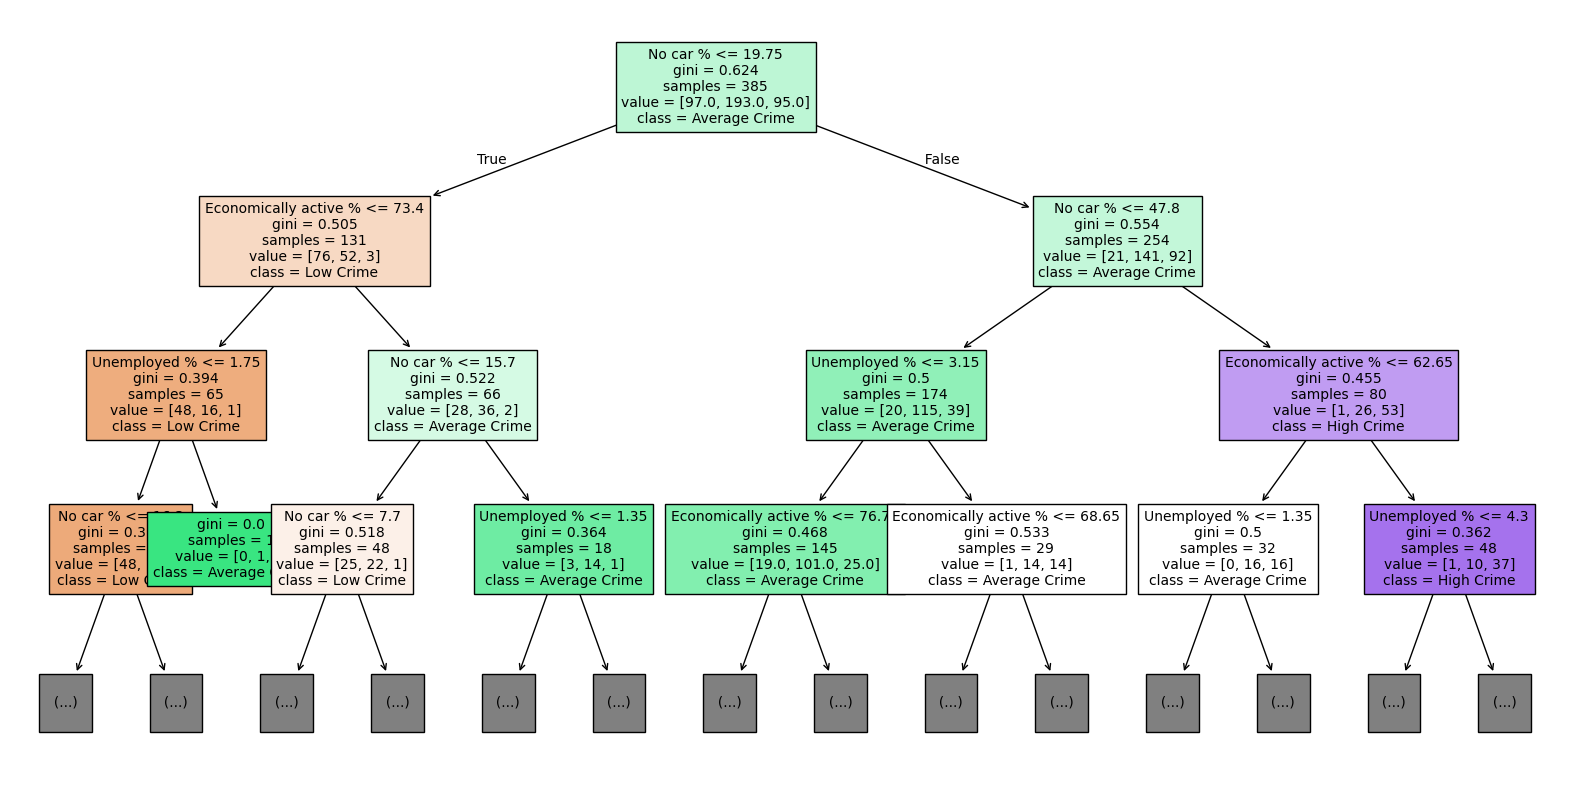

In [ ]:
fig = plt.figure(figsize=(20,10))
DecisionTree = plot_tree(crime_rate_decision_tree,
                         feature_names = ['No car %', 'Economically active %', 'Unemployed %'],
                         class_names = ['Low Crime', 'Average Crime', 'High Crime'],
                         max_depth = 3,
                         filled = True,
                         fontsize=10)

Here, we can see the 'thought process' of our Decision Tree model. The first decision it makes is based on lack of car ownership statistics, specifically a condition to check if rates are below or equal to 19.75. If True, the conditions shift to differentiating between low crime and average crime. If false, the opposite is true - although the tree seems more hesitant to proscribe high crime rate until a second condition is met based on even lower rates of car ownership. Based on the rest of the tree it would appear this first step is the only decision that separates areas of high crime and low crime. This fits what the correlation heatmap showed regarding 'No cars or vans in household % (2011)'.

## Part 3: K-Nearest Neighbor

K-Nearest Neighbor will be the second model tested on this data as it is also simple to implement and quick to run. It creates groups of close-proximity values within the data, predicting the class of individual values based on numerical closeness to neighbors. As it relies on the magnitude of training set values, KNN is very susceptible to large outliers - we should consider that these results may therefore be influenced by the extreme outliers of the city centre's crime rates.

A similar process is undertaken to train our KNN model. We can specify how many neighboring points to check for classification with <code>k</code>, which is set to 10.

In [ ]:
def TrainKNN(economic_data, crime_data):
    crime_labels = pd.qcut(crime_data, q=[0,0.25,0.75,1], labels=[1, 2, 3])
    training_data, testing_data, training_labels, testing_labels = train_test_split(
        economic_data,
        crime_labels,
        test_size = 0.20,
        random_state = 42)
    trained_knn = KNeighborsClassifier(n_neighbors = 10)
    trained_knn.fit(training_data, training_labels)
    print("K-Nearest Neighbor classifier has a score of", trained_knn.score(testing_data, testing_labels))
    return trained_knn

crime_rate_knn = TrainKNN(economic_array, crime_array)
IMD_knn = TrainKNN(economic_deprivation_array, crime_decile_array)

K-Nearest Neighbor classifier has a score of 0.6288659793814433
K-Nearest Neighbor classifier has a score of 0.6391752577319587


As mentioned earlier, KNN is vulnerable to bias from outliers. Below is what happens if we train KNN on a dataset with the outliers removed.

In [ ]:
crime_rate_knn_no_outliers = TrainKNN(LSOA_statistics_no_outliers[['No cars or vans in household % (2011)', 'Economically active % (2011)', 'Long-term unemployed % (2011)']].to_numpy(),
                                      LSOA_statistics_no_outliers['Crime Rate (2011)'].to_numpy())

K-Nearest Neighbor classifier has a score of 0.625


The score is roughly the same, so it appears our outliers have a neglible effect (however, this is always worth checking).

## Part 4: Multi-Layer Perceptron

The last kind of prediction model to try is the most ambitious and CPU-intensive. It is a Multi-Layer Perceptron, which implements deep learning by replicating an artificial neural network. Hence this model trains on an interative basis; as it descends each layer, variable weights are adjusted to lend greater bias to those that are stronger predictors. While the most advanced model we can use, it is generally more suited to large datasets while ours has only 482 records to learn from.

In [ ]:
Perceptron = MLPClassifier()

training_data, testing_data, training_labels, testing_labels = train_test_split(economic_array, crime_labels,
                                                                                stratify=crime_labels,
                                                                                test_size = 0.20,
                                                                                random_state=42)
crime_rate_mlp = MLPClassifier(random_state=42, max_iter=300).fit(training_data, training_labels)
crime_rate_mlp.predict_proba(testing_data)
crime_rate_mlp.predict(testing_data)
crime_rate_mlp.score(testing_data, testing_labels)

0.5360824742268041

The score of this model is 0.536, a result not quite up to par with the other methods.

# Results

With prediction performed with a variety of ML models, it is time to analyse the results. We will begin by evaluating the success of each model in-depth before looking at spatial maps of their predictions to better understand them from a geographic perspective. Finally, an examination of the learning curves of our ML models will be undertaken.

## Part 1: Model Evaluation

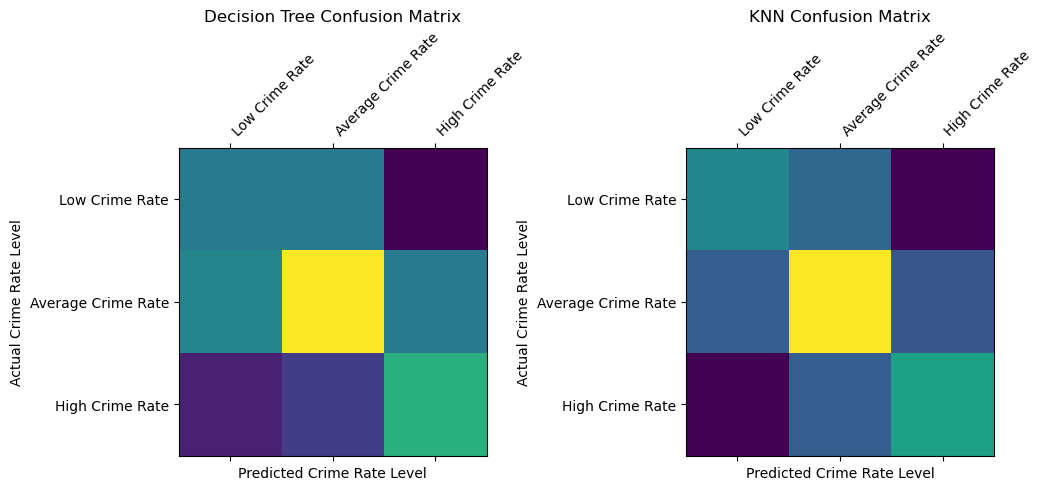

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       0.41      0.46      0.43        24
           2       0.59      0.51      0.55        47
           3       0.55      0.62      0.58        26

    accuracy                           0.53        97
   macro avg       0.51      0.53      0.52        97
weighted avg       0.53      0.53      0.53        97

K-NEAREST NEIGHBOR CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       0.61      0.58      0.60        24
           2       0.61      0.64      0.62        47
           3       0.68      0.65      0.67        26

    accuracy                           0.63        97
   macro avg       0.63      0.63      0.63        97
weighted avg       0.63      0.63      0.63        97



In [ ]:
training_data, testing_data, training_labels, testing_labels = train_test_split(economic_array, crime_labels, test_size = 0.20, random_state = 42)

dt_predictions = crime_rate_decision_tree.predict(testing_data)
knn_predictions = crime_rate_knn.predict(testing_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_labels = ["Low Crime Rate", "Average Crime Rate", "High Crime Rate"]

decision_tree_matrix = metrics.confusion_matrix(testing_labels,dt_predictions)
axes[0].matshow(decision_tree_matrix)
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted Crime Rate Level')
axes[0].set_ylabel('Actual Crime Rate Level')
axes[0].set_xticks(range(len(class_labels)))
axes[0].set_xticklabels(class_labels, rotation=45, ha="left")
axes[0].set_yticks(range(len(class_labels)))
axes[0].set_yticklabels(class_labels)

knn_matrix = metrics.confusion_matrix(testing_labels,knn_predictions)
axes[1].matshow(knn_matrix)
axes[1].set_title('KNN Confusion Matrix')
axes[1].set_xlabel('Predicted Crime Rate Level')
axes[1].set_ylabel('Actual Crime Rate Level')
axes[1].set_xticks(range(len(class_labels)))
axes[1].set_xticklabels(class_labels, rotation=45, ha="left")
axes[1].set_yticks(range(len(class_labels)))
axes[1].set_yticklabels(class_labels)
plt.show()

print("DECISION TREE CLASSIFICATION REPORT")
print(metrics.classification_report(testing_labels, dt_predictions, zero_division = 0))
print("K-NEAREST NEIGHBOR CLASSIFICATION REPORT")
print(metrics.classification_report(testing_labels, knn_predictions, zero_division = 0))

Above are the confusion matrices for predictions on the 2011 dataset. Each square in the grid ranges from dark blue to bright yellow based on the number of predictions made in that area. For example, a yellow square in [1, 0] indicates many predictions were made for 1 that turned out to actually be 0 in the test dataset. While a brighter colour on the matrix indicates more predictions in that area, it is not a measure of accuracy as these may be incorrectly placed or due to unevenly sized classes. There are several conclusions we can draw from these results:

* <b>Overall, KNN is the best simple prediction model for crime rates</b>. It has scored consistently higher than Decision Tree in all metrics.
* <b>KNN is best at identifying areas of high crime</b>, as evidenced by its precision being around 7% larger in class 3 than 1 and 2. This might also be due to the outliers' prescence in this test set creating a 'pull' towards the high crime class.
* <b>Decision Tree had a bias against predicting Average Crime Rates</b> as it was prone to predicting 0 and 2 when the actual label was 1.
* <b>Decision Tree was most accurate at predicting Average Crime Rates</b> as its precision was highest in that area. While Decision Tree was biased against this classification, it was right more often than not when it did predict this value.
* <b>KNN had minimal bias.</b> This conclusion is drawn from the confusion matrix, which has a colour scheme aligned to the diagonal axis without an imbalance of predictions.

Decision Tree classifier has a score of 0.6701030927835051
K-Nearest Neighbor classifier has a score of 0.6391752577319587


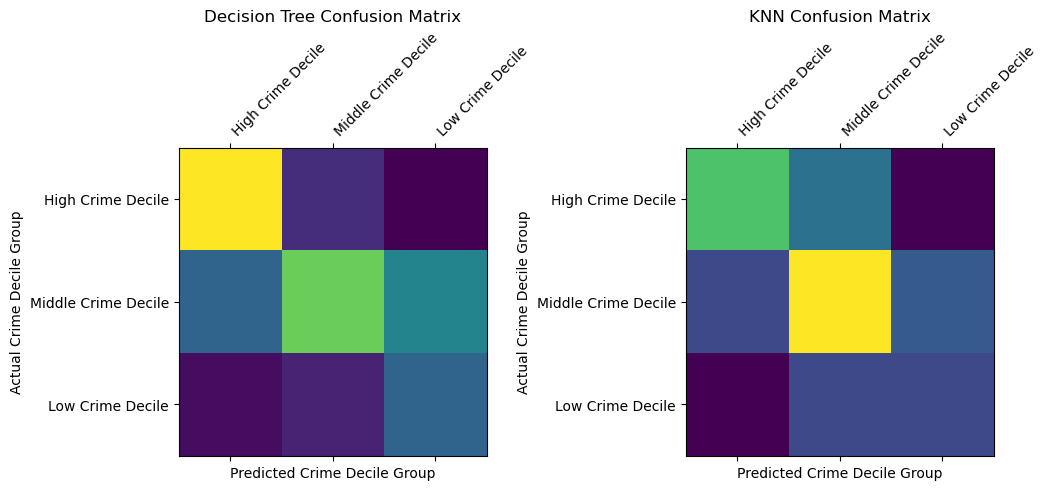

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       0.74      0.89      0.81        35
           2       0.77      0.50      0.61        48
           3       0.42      0.71      0.53        14

    accuracy                           0.67        97
   macro avg       0.64      0.70      0.65        97
weighted avg       0.71      0.67      0.67        97

K-NEAREST NEIGHBOR CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       0.77      0.66      0.71        35
           2       0.63      0.67      0.65        48
           3       0.44      0.50      0.47        14

    accuracy                           0.64        97
   macro avg       0.61      0.61      0.61        97
weighted avg       0.65      0.64      0.64        97



In [ ]:
crime_labels = pd.qcut(crime_decile_array, q=[0,0.25,0.75,1], labels=[1, 2, 3])
training_data, testing_data, training_labels, testing_labels = train_test_split(economic_deprivation_array, crime_labels, test_size = 0.20, random_state = 42)

IMD_decision_tree = TrainDecisionTree(economic_deprivation_array, crime_decile_array)
IMD_knn = TrainKNN(economic_deprivation_array, crime_decile_array)

dt_predictions = IMD_decision_tree.predict(testing_data)
knn_predictions = IMD_knn.predict(testing_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_labels = ["High Crime Decile", "Middle Crime Decile", "Low Crime Decile"]

decision_tree_matrix = metrics.confusion_matrix(testing_labels,dt_predictions)
axes[0].matshow(decision_tree_matrix)
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted Crime Decile Group')
axes[0].set_ylabel('Actual Crime Decile Group')
axes[0].set_xticks(range(len(class_labels)))
axes[0].set_xticklabels(class_labels, rotation=45, ha="left")
axes[0].set_yticks(range(len(class_labels)))
axes[0].set_yticklabels(class_labels)

knn_matrix = metrics.confusion_matrix(testing_labels,knn_predictions)
axes[1].matshow(knn_matrix)
axes[1].set_title('KNN Confusion Matrix')
axes[1].set_title('KNN Confusion Matrix')
axes[1].set_xlabel('Predicted Crime Decile Group')
axes[1].set_ylabel('Actual Crime Decile Group')
axes[1].set_xticks(range(len(class_labels)))
axes[1].set_xticklabels(class_labels, rotation=45, ha="left")
axes[1].set_yticks(range(len(class_labels)))
axes[1].set_yticklabels(class_labels)
plt.show()


print("DECISION TREE CLASSIFICATION REPORT")
print(metrics.classification_report(testing_labels, dt_predictions, zero_division = 0))
print("K-NEAREST NEIGHBOR CLASSIFICATION REPORT")
print(metrics.classification_report(testing_labels, knn_predictions, zero_division = 0))

Interestingly, the opposite case is true with IMD data: <b>the Decision Tree method is generally more accurate than KNN for crime deciles</b>. It is important to clarify to avoid confusion: a 'Low Crime Decile' is negative, as it means an LSOA in ranked within the bottom 10% on crime (And hence has higher crime rates).

* <b>KNN was best at identifying Low Crime Deciles</b>. Much like the model trained on 2011 data, KNN can better predict where crime hotspots will emerge.
* <b>Decision Tree had higher recall values for low and high deciles</b>, at 0.89 and 0.71 for above and below average deciles. This means that it correctly identified a larger proportion of positive cases for non-average crime deciles.
* <b>Both trees were least accurate with High Crime Deciles</b>, evidenced by the darker colour in the [3, 3] square and low ~0.4 precision scores with those labels. This may have been influenced by the lower number of '3' cases in the testing dataset - the support column shows a value of 14 compared to 35 and 48 for other labels.
* <b>KNN was biased towards Middle and Low Crime Deciles</b>, shown by the brighter colours in the top left and middle squares of its confusion matrix.


## Part 2: Prediction Maps

Now we will plot our predictions spatially by appending an array of predicted crime levels to each of the original datasets. For each map we will use the model with the greatest performance as determined in Part 1. We will need to re-predict crime values to create these maps, although the predictions will be nearly identical to those used in Part 1 so it should not impact the analysis.

([], [])

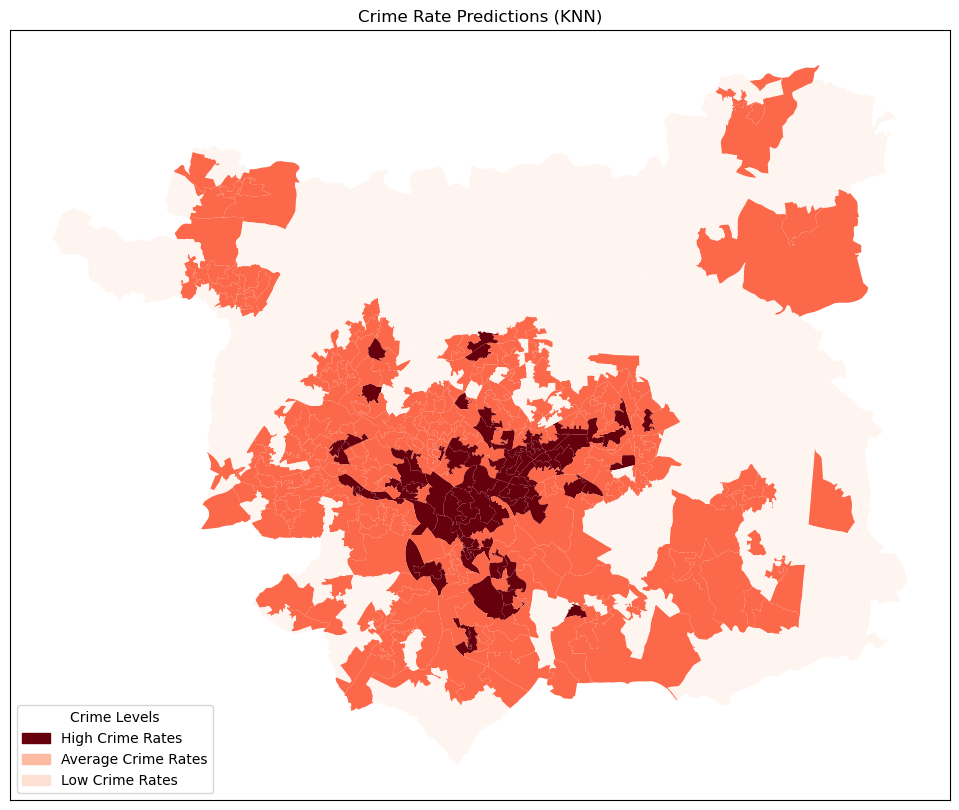

In [ ]:
knn_predictions = crime_rate_knn.predict(economic_array)

LSOA_statistics['predictions'] = pd.Series(knn_predictions)
ax = LSOA_statistics.plot(column="predictions", cmap="Reds",  figsize=(18, 10))
ax.set_title("Crime Rate Predictions (KNN)")

# Create custom legend for readability
high_crime = mpatches.Patch(color="#67000d", label="High Crime Rates")
average_crime = mpatches.Patch(color="#fcbba1", label="Average Crime Rates")
low_crime = mpatches.Patch(color="#fee0d2", label="Low Crime Rates")
plt.legend(handles=[high_crime, average_crime, low_crime], loc="lower left", title="Crime Levels")
plt.xticks([])
plt.yticks([])

At first impressions this map is visually similar to the spatial map of crime rates produced earlier, which is a good sign. Some patterns can be observed at a glance:

* There are four main clusters of increased crime rates. As expected they line up with more populated areas - namely Leeds, Otley, Wetherby and Bramham.
* Crime Rates are consistently high near the city centre and Harehills ward.
* Average Crime Rates roughly align with the borders of Leeds' built-up area.
* High Crime Rates appear sporadically in mini-clusters outside the city centre.
* Crime Rates are low in rural, sparsely-populated areas.

([], [])

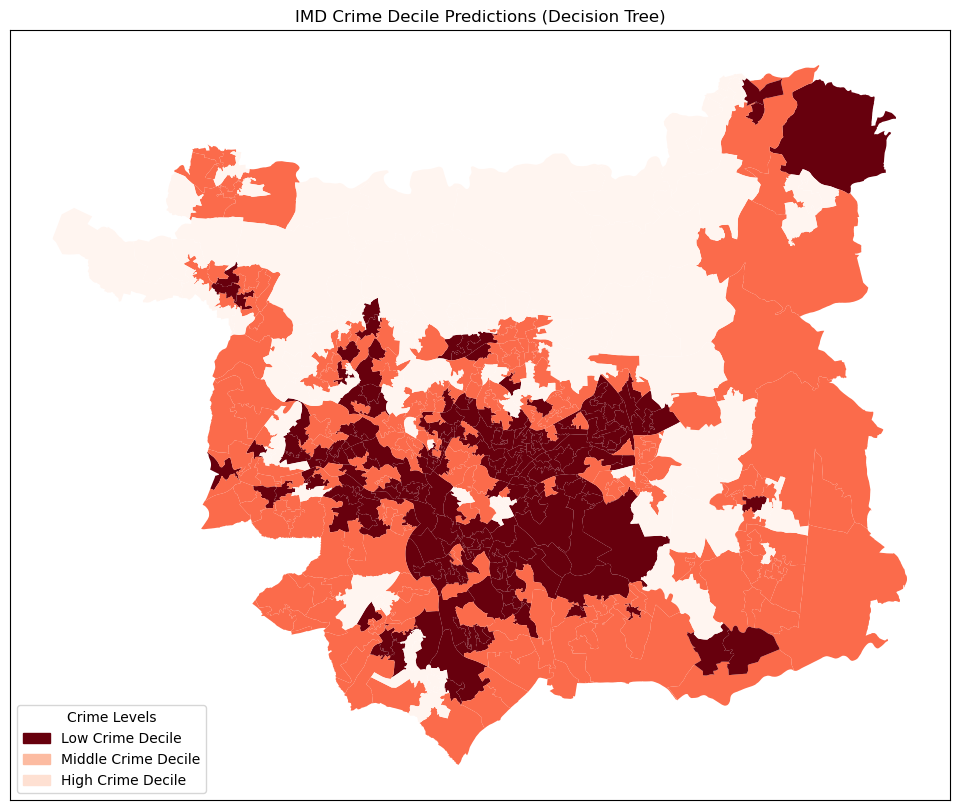

In [ ]:
predictions = IMD_decision_tree.predict(economic_deprivation_array)

deprivation_by_LSOA['predictions'] = pd.Series(predictions)

ax = deprivation_by_LSOA.plot(column="predictions", cmap="Reds_r", figsize=(16, 10))
ax.set_title("IMD Crime Decile Predictions (Decision Tree)")

# Create custom legend for readability
high_crime = mpatches.Patch(color="#67000D", label="Low Crime Decile")
average_crime = mpatches.Patch(color="#FCBBA1", label="Middle Crime Decile")
low_crime = mpatches.Patch(color="#FEE0D2", label="High Crime Decile")
plt.legend(handles=[high_crime, average_crime, low_crime], loc="lower left", title="Crime Levels")
plt.xticks([])
plt.yticks([])

There are notable differences from the map created from 2011 Census data. However, it should be kept in mind that these maps use different measures of crime - A 'Low Crime Decile' may encompass a wider range of values than a 'High Crime Rate' statistic, giving the appearance of more crime on this map.

* A large proportion of Leeds is within lower crime deciles.
* This map is not subdivided into clusters of crime rates - instead, all crime hotspots seem more evenly spread across the Leeds metropolitan area.
* Southern, western and eastern rural areas have middle crime deciles. This is in contrast to the previous map predicting lower crime rates for these areas.
* The City Centre is in the middle to high crime deciles. Notably, the University of Leeds campus is also in the middle deciles despite the low-decile LSOAs surrounding these areas.

## Part 3: Learning Curves

To understand and how we might improve our models in future, we can plot their learning progress over different training set sizes.

In [ ]:
economic_array = LSOA_statistics[['No cars or vans in household % (2011)', 'Economically active % (2011)', 'Long-term unemployed % (2011)']].to_numpy()
crime_array = LSOA_statistics['Crime Rate (2011)'].to_numpy()
crime_labels = pd.qcut(crime_array, q=[0,0.25,0.75,1], labels=labels)

<code>train_sizes</code> represents how many iterations of training we want to run through. It is set to 10 here.

In [ ]:
learning_curve_parameters = {
    "X": economic_array,
    "y": crime_labels,
    "train_sizes": np.linspace(0.1, 1.0, 10),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=42),
    "score_type": "both",
    "n_jobs": 10,
    "line_kw": {"marker": "o"},
    "score_name": "Score",
    "shuffle" : True,
    "random_state": 42
}

Now all that remains is to run the learning curve function and plot the results.

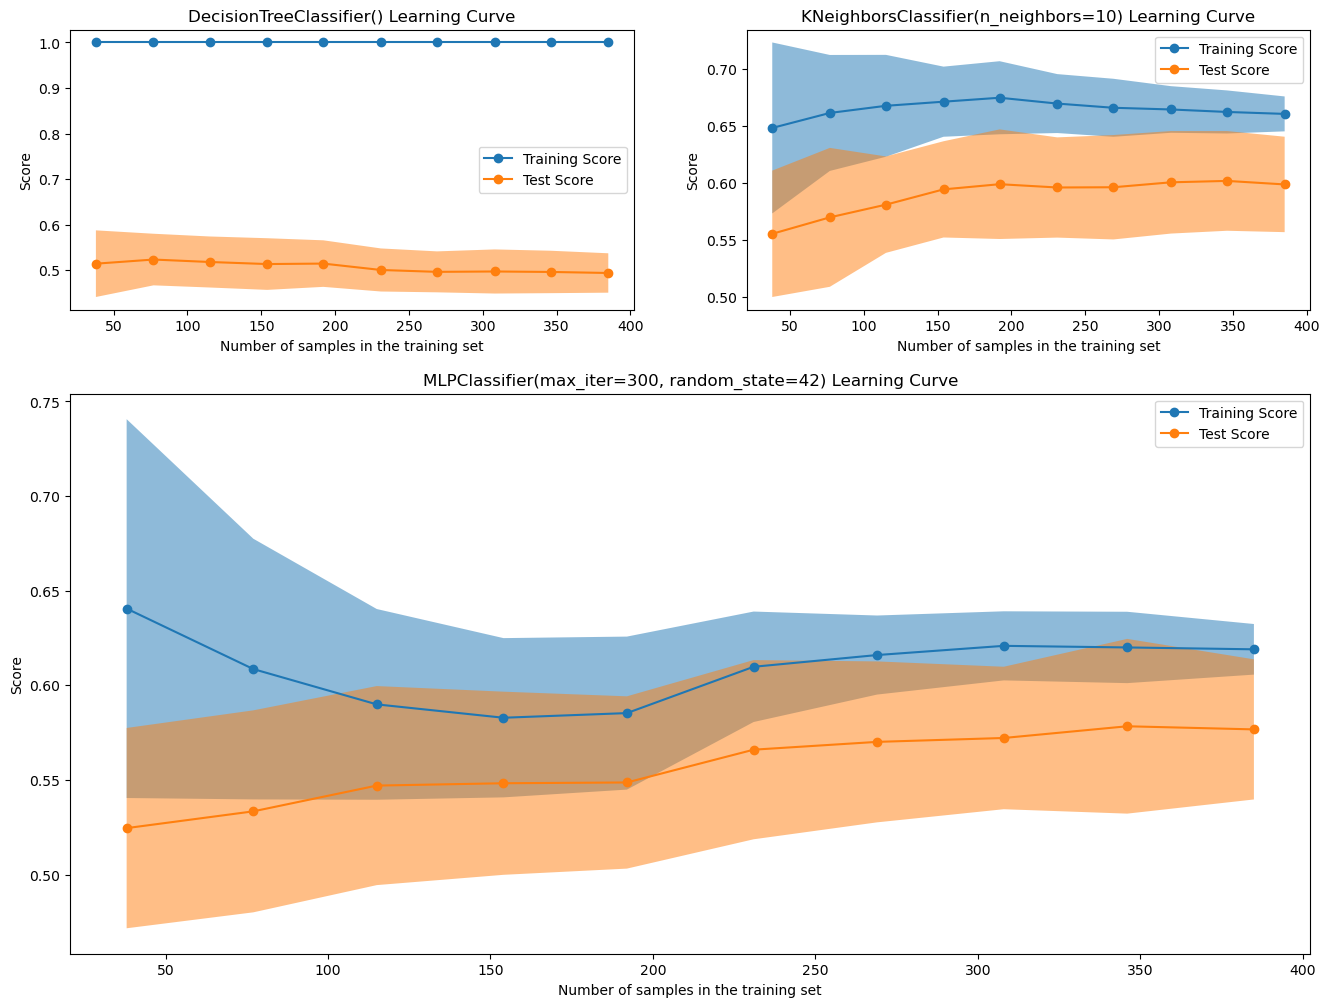

In [ ]:
def LearningCurveGraphs():
    fig = plt.figure(figsize=(16, 12))
    spec = GridSpec(nrows=2, ncols=2, height_ratios=[1, 2], figure=fig)

    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[0, 1])
    ax3 = fig.add_subplot(spec[1, :])

    for index, (Classifier, ax) in enumerate(zip([crime_rate_decision_tree, crime_rate_knn, crime_rate_mlp], [ax1, ax2, ax3])):
        LearningCurveDisplay.from_estimator(Classifier, **learning_curve_parameters, ax=ax)
        handles, label = ax.get_legend_handles_labels()
        ax.legend(handles[:2], ["Training Score", "Test Score"])
        ax.set_title(str(Classifier) + " Learning Curve")

    plt.show()

LearningCurveGraphs()

* <b>Test scores are broadly lower than training scores in all training iterations</b>. This is expected as testing data is unseen by the model - there is bound to be a loss of accuracy from this, but the smaller the gap the better.
* <b>Decision Tree models had a consistent training score of 1.0 and a gradually decreasing test score with larger sets</b>. This combined with the large gap between training and test scores indicate that <b>Decision Tree models were overfitting on 2011 data</b>. Overfitting means that our model had become so accustomed to the training data that it was unable to predict effectively on unseen variables.
* <b>KNN models steadily increase in accuracy with training set size until they reach ~200 training samples</b>, at which point test and training scores begin to plateau.
* The Perceptron initially follows a typical learning curve until it reaches the ~200 threshold. What follows is a sharp uptick in training and test scores that subsequently plateaus similar to KNN.
* <b>The optimal number of training samples for most ML models is around 175-250 with this dataset</b>, though this number will vary based on the model used.

# Discussion

The outcomes of this project's data analysis have told us a great deal about Machine Learning in the context of crime prediction. Firstly, the factors that primarily influence crime rates have been discovered through our initial statistical analysis - although the machine learning process has reinforced these conclusions by exhibiting the effects these variables have on prediction. For the 2011 dataset, lack of car ownership (defined as the 'No cars or vans in household % (2011)' column) had the largest correlation with crime. The Decision Tree model in particular used this statistic to make its initial classification between low or high crime rates. There are real-world reasons for why this aspect is so important. As mentioned before, Dargay (2001) states that car ownership is tied to higher incomes, which generally means there will be less crime committed due to a lack of motivation. Our correlation heatmap supports this statement with the strong positive correlation (0.77) between unemployment and lack of a car. Building on this is the fact that our spatial prediction maps showed low crime rates in rural areas - places which are highly car-dependent (Department for Transport, 2020). In the IMD dataset, two strong predictors were identified in the Health and Income Deciles of Leeds LSOAs. While Income could be linked with the previously-discussed variable, Health has a less clear (and altogether unexpected) association with crime that may require further investigation.

The best-working models for Leeds varied depending on the dataset. KNN was effective with 2011 census data, while Decision Tree trained on IMD data was most accurate with 2019 IMD data but also achieved the best score overall. This helps illustrate the differences between economic-based predictions of crime and those that focus on deprivation metrics. It may be that by examining the more explicitly negative factors of LSOAs, the prescence of high crime rates is easier to identify. This outlook does seem to parallel that of the UK government, which currently uses the Indices of Multiple Deprivation to determine where to allocate billions in public spending to alleviate social problems including crime (Lloyd et al., 2022). The practical applications of this final model are therefore evident as a government tool working in conjuction with gathered IMD data. Neighborhoods with high crime could be located in the absence of concrete police data - especially since a great deal of crime goes unrecorded due to its secrecy. Although there is room for improvement, especially in terms of accuracy. More strongly correlated variables could be included in training, for instance. This would of course require more real-world data, so a balance may have to be struck between variable quality and efficiency.

Some further questions have been brought to light by this analysis. We have established what variables are strong predictors of crime, for instance, but additional work could be done to determine whether these relationships are causal in nature. Factors such as Income Decile would be good candidates for this kind of analysis as personal wealth (or lack thereof) has a strong effect on a persons motivations and means (). There is also the possibility that we are missing key real-world context that might help our models' accuracy. Brantingham and Brantingham's (1982) theory of criminal awareness spaces implies there is a spatial dimension of crime to consider - especially since many criminals will travel from their home LSOAs to commit crimes. It is believed this phenomena was on display with the extreme crime rates of the city centre; a rich area that would most likely be less of a crime hotspot if not for its strategic location as a transport hub. Hence, in a future project it might be prudent to include 'transport links' or 'distance to city centre' as a variable. Naturally, the question of spatial influence can be extended further: is Leeds a unique case, or do all UK cities follow the trends shown in this project?

# Conclusion

In short, this project could be considered a success. While the perfect model has yet to be developed, the research question has been addressed by evaluating the viability of Machine Learning as a whole in the area of criminology. By observing how ML models interpret input variables we have gained a greater understanding as to how economic factors influence crime, and found ways to optimise their learning processes. The outcomes of this project have produced a series of visualisations for the effectiveness of various Machine Learning models as well as what could be considered a 'test run' on real Leeds data. In retrospect, the Urban Science context of this project can be considered a hybrid of two fields - urban socioeconomics and urban crime. The fact that these two statisical areas are interconnected has implications about the complex nature of cities, namely that subsystems within cities exist and can feed into eachother. Not only that, but these subsystems can be mapped and quantified enough to predict their behaviours with reasonable accuracy. The Health Decile's unanticipated importance leads us to believe there are 'hidden' relationships between neighborhood attributes that machine learning may help uncover or explain.

# References

Allison, J. 1972. Economic Factors and the Rate of Crime. <i>Land Economics</i>. [Online]. <b>48</b>(2), pp.193-196. [Accessed 13 January 2025]. Available from: <a>https://doi.org/10.2307/3145482</a>

Bennett, T., and Holloway, K. 2004. Gang Membership, Drugs and Crime in the UK. <i>The British Journal of Criminology</i>. [Online]. <b>44</b>(3), pp.305-323. [Accessed 10 January 2025]. Available from: <a>https://doi.org/10.1093/bjc/azh025</a>

Churchill, D. 2013. <i>Crime, policing and control in Leeds, c1830-1890</i>. PhD thesis, The Open University. Available from: <a>https://www.proquest.com/openview/c0d62ac6758be6e5fda07ddea057e17a/1?pq-origsite=gscholar&cbl=51922&diss=y</a>

Dargay, J. 2001. The effect of income on car ownership: evidence of asymmetry. <i>Transportation Research Part A: Policy and Practice</i>. [Online]. <b>35</b>(9), pp.807-821. [Accessed 22 January 2025]. Available from: <a>https://doi.org/10.1016/S0965-8564(00)00018-5</a>

Department for Communities and Local Government. 2015. <i>The English Index of Multiple Deprivation (IMD) 2015 – Guidance</i>. [Online]. London: The National Archives. [Accessed 16 January 2025]. Available from: <a>https://assets.publishing.service.gov.uk/media/5a7f0e5ded915d74e33f410b/English_Index_of_Multiple_Deprivation_2015_-_Guidance.pdf</a>

Department for Transport. 2020. <i>Future of Transport: rural strategy – call for evidence</i>. [Online]. London: The National Archives. [Accessed 24 January 2025]. Available from: <a>https://www.gov.uk/government/calls-for-evidence/future-of-transport-rural-strategy-call-for-evidence</a>

Dnes, A. 2000. The Economics of Crime. In: <i> The Economic Dimensions of Crime</i>. [Online]. London: Palgrave Macmillan, pp.69-81. [Accessed 24 January 2025]. Available from: <a>https://doi.org/10.1007/978-1-349-62853-7_3</a>

Freeman, S., Grogger, J. and Sonstelie, J. 1996. The Spatial Concentration of Crime. <i>Journal of Urban Economics</i>. [Online]. <b>40</b>(2), pp.216-231. [Accessed 13 January 2025]. Available from: <a>https://doi.org/10.1006/juec.1996.0030</a>

Gulma, U. 2022. A new geodemographic classification of the influence of neighbourhood characteristics on crime: The case of Leeds, UK. <i>Computers, Environment and Urban Systems</i>. [Online]. <b>92</b>, article no: 101748 [no pagination]. [Accessed 22 January]. Available from: <a>https://doi.org/10.1016/j.compenvurbsys.2021.101748</a>

Hardyns, W. and Rummens, A. 2017. Predictive Policing as a New Tool for Law Enforcement?
Recent Developments and Challenges. <i>European Journal on Criminal Policy and Research</i>. <b>24</b>, pp.201-218. [Accessed 17 January]. Available from: <a>https://doi.org/10.1007/s10610-017-9361-2</a>

Kongmuang, C. 2006. <i>Modelling Crime: A Spatial Microsimulation Approach</i>. Ph.D. thesis, University of Leeds. Available from: https://www.researchgate.net/profile/Charatdao-Kongmuang/publication/272684990_Modelling_Crime_A_Spatial_Microsimulation_Approach/links/550002b90cf2672e22495879/Modelling-Crime-A-Spatial-Microsimulation-Approach.pdf

Lloyd, C., Norman, P. and McLennan, D. 2022. Deprivation in England, 1971–2020. <i>Applied Spatial Analysis and Policy</i>. [Online]. <b>16</b>, pp.461-484. [Accessed 24 January 2025]. Available from: <a>https://doi.org/10.1007/s12061-022-09486-8</a>

Meijer, A. and Wessels, M. 2019. Predictive Policing: Review of Benefits and Drawbacks. <i>International Journal of Public Administration</i>. [Online]. <b>42</b>(12), pp.1031-1039. [Accessed 17 January 2025]. Available from: <a>https://doi.org/10.1080/01900692.2019.1575664</a>

Ministry of Housing, Communities & Local Government (2018 to 2021). 2019. <i>English indices of deprivation 2019</i>. [Online]. London: The National Archives. [Accessed 19 January 2025]. Available from: <a>https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019</a>

Nichols, A., Mitchell, J., Lindner, S. 2013. <i>Consequences of Long-Term Unemployment</i>. [Online]. Washington, D.C: The Urban Institute. [Accessed 16 January 2025]. Available from: <a>https://www.urban.org/sites/default/files/publication/23921/412887-Consequences-of-Long-Term-Unemployment.PDF?source=post_page</a>

Seddon, T. 2006. Drugs, Crime and Social Exclusion: Social Context and Social Theory in British Drugs–Crime Research. <i>The British Journal of Criminology</i>. [Online]. <b>46</b>(4), pp.680-703. [Accessed 11 January 2025]. Available from: <a>https://doi.org/10.1093/bjc/azi079</a>

Wilcox, P. and Cullen, F. 2018. Situational Opportunity Theories of Crime. <i>Annual Review of Criminology</i>. [Online]. <b>1</b>, pp.123-148. [Accessed 23 January 2025]. Available from: <a>https://doi.org/10.1146/annurev-criminol-032317-092421</a>









In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java
  libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3
  libcommons-logging-java libcommons-parent-java libfontbox-java libfontenc1
  libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0 libkpathsea6
  libpdfbox-java libptexenc1 libruby3.0 libsynctex2 libteckit0 libtexlua53
  libtexluajit2 libwoff1 libzzip-0-13 lmodern pandoc-data poppler-data
  preview-latex-style rake ruby ruby-net-telnet ruby-rubygems ruby-webrick
  ruby-xmlrpc ruby3.0 rubygems-integration t1utils teckit tex-common tex-gyre
  texlive-base texlive-binaries texlive-latex-base texlive-latex-extra
  texlive-latex-recommended texlive-pictures tipa xfonts-encodings
  xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-free

In [5]:
!jupyter nbconvert --to pdf /content/drive/MyDrive/ColabNotebooks/JosephMarshAssignment2.ipynb

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/ColabNotebooks/JosephMarshAssignment2.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent